<a href="https://colab.research.google.com/github/elizabethvillones88-alt/smart-waste-bin-iot/blob/main/A02_Statistics_Villones.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LinearRegression

In [80]:
df = pd.read_csv("Lvl6_AllRRUOn_Anomaly_label.csv")
df = pd.read_csv("Lvl6_1RRUOn_Anomaly_label.csv")
df = pd.read_csv("Lvl5_AllRRUOn_Anomaly_label.csv")
df = pd.read_csv("Lvl4_AllRRUOn_Anomaly_label.csv")
df = pd.read_csv("Lvl4_AllRRUOn_Anomaly_label.csv")

df.head()

,Time,NR-ARFCN,PCI,_oid,RSRP,RSRQ,SINR,PDSCH_MCS,PUSCH_MCS,PDSCH PRBs,PUSCH PRBs,throughput_DL,C-RNTI,Corridor_tag,lab_anom,lab_bs,lab_inf,lab_1rr,Label
0,2022-10-04 15:52:22.917,628416,17,1350791784,-107.199997,-10.5,17.1,19.0,12.0,128.0,4.0,237685760,13853,0,0,0,0,0,0
1,2022-10-04 15:52:23.435,628416,17,1350791784,-105.000000,-10.4,18.9,19.0,13.0,128.0,4.0,237685760,13853,0,0,0,0,0,0
2,2022-10-04 15:52:23.949,628416,17,1350791784,-101.400002,-10.4,20.5,19.0,13.0,128.0,4.0,237685760,13853,0,0,0,0,0,0
3,2022-10-04 15:52:24.471,628416,17,1350791784,-102.199997,-10.3,18.9,18.0,12.0,128.0,4.0,193200128,13853,0,0,0,0,0,0
4,2022-10-04 15:52:24.990,628416,17,1350791784,-102.099998,-10.3,21.0,18.0,12.0,129.0,4.0,193200128,13853,0,0,0,0,0,0


In [82]:
df = df[['Time', 'throughput_DL', 'RSRP', 'RSRQ', 'SINR']].dropna()
df.rename(columns={'throughput_DL': 'throughput'}, inplace=True)

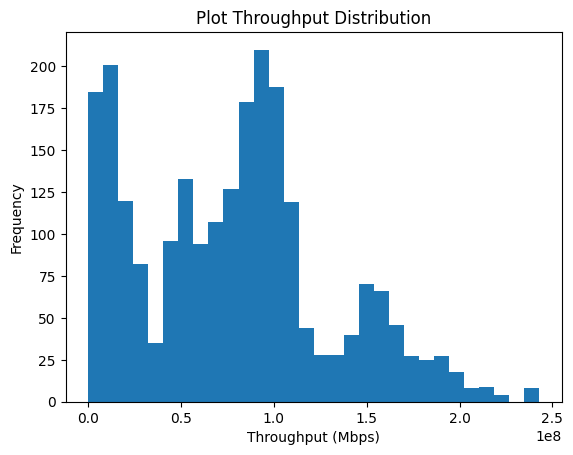

In [95]:
plt.hist(df['throughput'], bins=30)
plt.xlabel('Throughput (Mbps)')
plt.ylabel('Frequency')
plt.title('Plot Throughput Distribution')
plt.show()

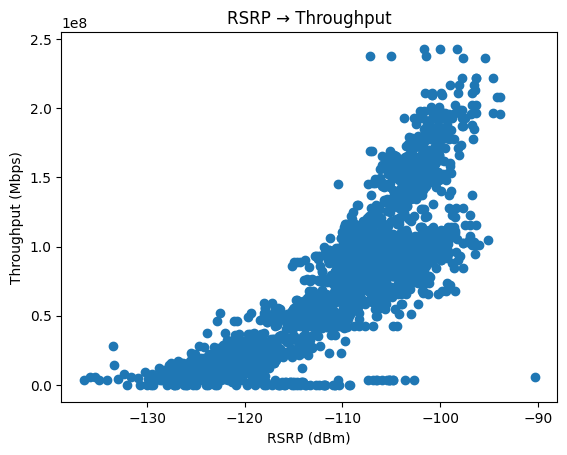

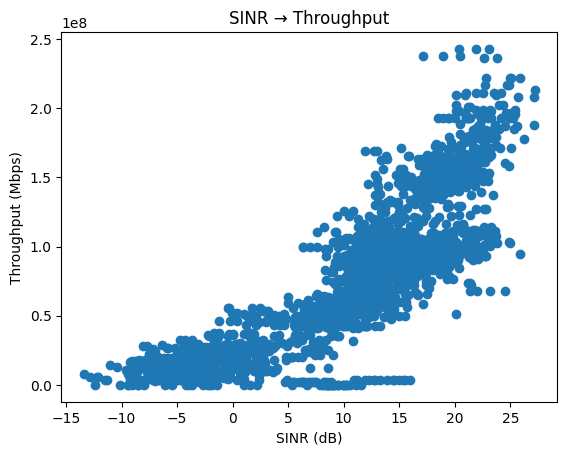

In [98]:
plt.scatter(df['RSRP'], df['throughput'])
plt.xlabel('RSRP (dBm)')
plt.ylabel('Throughput (Mbps)')
plt.title('RSRP → Throughput')
plt.show()

plt.scatter(df['SINR'], df['throughput'])
plt.xlabel('SINR (dB)')
plt.ylabel('Throughput (Mbps)')
plt.title('SINR → Throughput')
plt.show()

In [86]:
mean = df['throughput'].mean()
sem = stats.sem(df['throughput'])
ci = stats.t.interval(0.95, len(df)-1, loc=mean, scale=sem)

print("Mean:", mean)
print("95% CI:", ci)

Mean: 77837040.07056798
95% CI: (np.float64(75714927.47159888), np.float64(79959152.66953708))


In [96]:
group1 = df[df['SINR'] > 10]['throughput']
group2 = df[df['SINR'] <= 10]['throughput']

t_stat, p_val = stats.ttest_ind(group1, group2, equal_var=False)

print("p-value:", p_val)

p-value: 0.0


In [89]:
print("RSRP correlation:", df['RSRP'].corr(df['throughput']))
print("SINR correlation:", df['SINR'].corr(df['throughput']))

RSRP correlation: 0.830002568641726
SINR correlation: 0.8381540402783975


In [90]:
X = df[['SINR']]
y = df['throughput']

model = LinearRegression()
model.fit(X, y)

print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)
print("R^2:", model.score(X, y))

Slope: 5024684.069489171
Intercept: 24078325.677802786
R^2: 0.7025021952350021


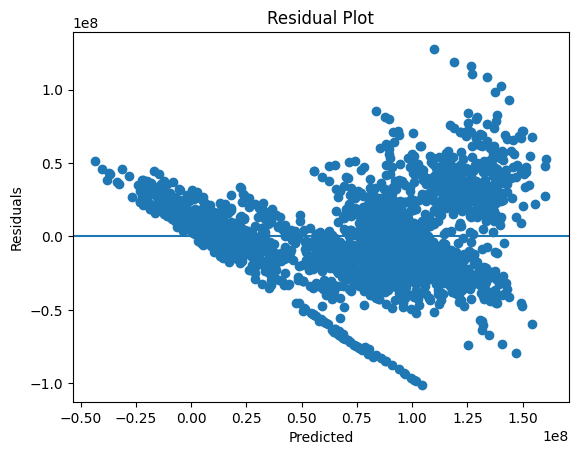

In [97]:
pred = model.predict(X)
residuals = y - pred

plt.scatter(pred, residuals)
plt.axhline(0)
plt.xlabel('Predicted')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()